#                                  timeseris Multi Label Clasification - GRU

# Load Data

In [1]:
import pandas as pd
import os
import numpy as np

In [2]:

file_name = "microsoft_stock_data"
root_folder = f'timeseris/multi-label-clasification/rnn/{file_name}/' 
os.makedirs(root_folder, exist_ok=True)

df = pd.read_csv('sample_data/'+file_name+'.csv')

df.head()

,Date,Close,High,Low,Open,Volume
0,3/26/1986,0.057906,0.058437,0.055781,0.056312,22752000
1,3/27/1986,0.058969,0.058969,0.057906,0.057906,16848000
2,3/31/1986,0.058437,0.058969,0.057375,0.058969,12873600
3,4/1/1986,0.057906,0.058437,0.057906,0.058437,11088000
4,4/2/1986,0.058437,0.059500,0.057906,0.057906,27014400


#### Pilih tahun mulai data

In [3]:
# Pastikan kolom Date dalam format datetime
df['Date'] = pd.to_datetime(df['Date'])

# Filter data mulai dari tahun 2000
df = df[df['Date'] >= '1999-01-01']

# (Opsional) urutkan berdasarkan tanggal
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Close,High,Low,Open,Volume
0,1999-01-04,21.572977,22.223226,21.324352,21.360212,69305200
1,1999-01-05,22.414471,22.643970,21.639909,21.706847,64281600
2,1999-01-06,23.141226,23.179476,22.452727,22.873476,69064800
3,1999-01-07,23.026478,23.045603,22.682228,22.911728,51150400
4,1999-01-08,22.930851,23.332476,22.490976,23.284663,50244800


#### tambahkan status green, red, dan netral || DayName

In [4]:
# === Tambahkan kolom nama hari ===
df['Day'] =  df['Date'].dt.day_name()  # bahasa Inggris

# Buat kondisi
conditions = [
    df['Close'] > df['Open'],
    df['Close'] < df['Open'],
    df['Close'] == df['Open']
]
choices = ['green', 'red', 'red']

df['Status'] = np.select(conditions, choices)
df.head()

,Date,Close,High,Low,Open,Volume,Day,Status
0,1999-01-04,21.572977,22.223226,21.324352,21.360212,69305200,Monday,green
1,1999-01-05,22.414471,22.643970,21.639909,21.706847,64281600,Tuesday,green
2,1999-01-06,23.141226,23.179476,22.452727,22.873476,69064800,Wednesday,green
3,1999-01-07,23.026478,23.045603,22.682228,22.911728,51150400,Thursday,green
4,1999-01-08,22.930851,23.332476,22.490976,23.284663,50244800,Friday,red


#### Chart Donat

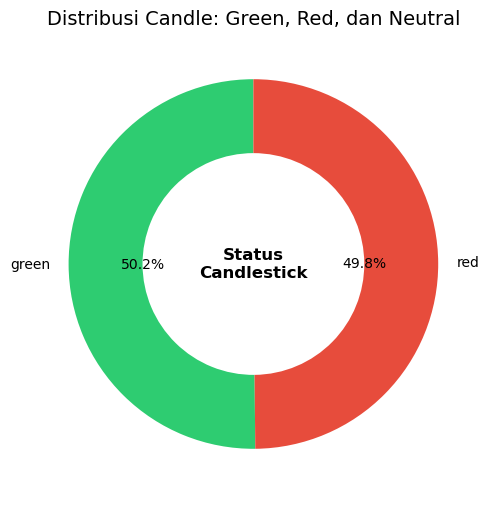

In [5]:
import matplotlib.pyplot as plt

# Contoh: df sudah punya kolom Status
# (kalau belum, bisa pakai kode sebelumnya untuk menambahkannya)

# Hitung jumlah masing-masing status
status_counts = df['Status'].value_counts()

# Warna donat
colors = {
    'green': '#2ecc71',   # hijau
    'red': '#e74c3c',     # merah
    'neutral': '#95a5a6'  # abu-abu
}

# Buat donut chart
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[colors[k] for k in status_counts.index],
    wedgeprops=dict(width=0.4)  # buat efek donut
)

# Tambahkan teks di tengah
ax.text(0, 0, 'Status\nCandlestick', ha='center', va='center', fontsize=12, weight='bold')

plt.title('Distribusi Candle: Green, Red, dan Neutral', fontsize=14)
plt.show()

In [6]:
status_counts

Status
green    3381
red      3359
Name: count, dtype: int64

#### LabelEncoder

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
#labeling
df['label_Day']            = le.fit_transform(df['Day'])
df.head()

,Date,Close,High,Low,Open,Volume,Day,Status,label_Day
0,1999-01-04,21.572977,22.223226,21.324352,21.360212,69305200,Monday,green,1
1,1999-01-05,22.414471,22.643970,21.639909,21.706847,64281600,Tuesday,green,3
2,1999-01-06,23.141226,23.179476,22.452727,22.873476,69064800,Wednesday,green,4
3,1999-01-07,23.026478,23.045603,22.682228,22.911728,51150400,Thursday,green,2
4,1999-01-08,22.930851,23.332476,22.490976,23.284663,50244800,Friday,red,0


#### Scaler

In [8]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Contoh: buat dan fit scaler
scaler = MinMaxScaler()
cols = [
    'label_Day',
    'Close', 
    'High', 
    'Low',
    'Open',
    'Volume', 
]

# Dictionary untuk menyimpan hasil transformasi
scaled_data = {}

# Loop untuk setiap kolom
for col in cols:
    scaler = MinMaxScaler()
    df[[col]] = scaler.fit_transform(df[[col]])  # scaling per kolom
    joblib.dump(scaler, os.path.join(root_folder, f'scaler_{col}.pkl'))
    scaled_data[col] = scaler
    print(f"✅ Scaler for '{col}' saved as scaler_{col}.pkl")

print("\nAll individual scalers saved successfully!")

✅ Scaler for 'label_Day' saved as scaler_label_Day.pkl
✅ Scaler for 'Close' saved as scaler_Close.pkl
✅ Scaler for 'High' saved as scaler_High.pkl
✅ Scaler for 'Low' saved as scaler_Low.pkl
✅ Scaler for 'Open' saved as scaler_Open.pkl
✅ Scaler for 'Volume' saved as scaler_Volume.pkl

All individual scalers saved successfully!


In [9]:
df.head()

,Date,Close,High,Low,Open,Volume,Day,Status,label_Day
0,1999-01-04,0.019888,0.019737,0.019942,0.018714,0.106426,Monday,green,0.25
1,1999-01-05,0.021495,0.020511,0.020549,0.019352,0.097822,Tuesday,green,0.75
2,1999-01-06,0.022883,0.021498,0.022111,0.021500,0.106014,Wednesday,green,1.00
3,1999-01-07,0.022664,0.021251,0.022553,0.021571,0.075333,Thursday,green,0.50
4,1999-01-08,0.022482,0.021779,0.022185,0.022257,0.073782,Friday,red,0.00


#### Mapping label

In [10]:
import json
mapping_dicts = {}

cols = [
    'Day',
]

for col in cols:
    label_col = f"label_{col}"
    mapping_dicts[col] = dict(zip(df[col], df[label_col]))


with open(root_folder + 'label_mappings.json', 'w') as f:
    json.dump(mapping_dicts, f, indent=2)

rows = []
for col, mapping in mapping_dicts.items():
    for k, v in mapping.items():
        rows.append({'feature': col, 'original_value': k, 'label_value': v})

mapping_table = pd.DataFrame(rows)
print(mapping_table)

  feature original_value  label_value
0     Day         Monday         0.25
1     Day        Tuesday         0.75
2     Day      Wednesday         1.00
3     Day       Thursday         0.50
4     Day         Friday         0.00


#### Select Kolom To Trian

In [11]:
col_target = 'Status'
cols = [
    'Date',
    'label_Day', 
    'Close', 
    'High',
    'Low',
    'Open',
    'Volume',
    col_target
]
df = df[cols].copy()
df.head()

,Date,label_Day,Close,High,Low,Open,Volume,Status
0,1999-01-04,0.25,0.019888,0.019737,0.019942,0.018714,0.106426,green
1,1999-01-05,0.75,0.021495,0.020511,0.020549,0.019352,0.097822,green
2,1999-01-06,1.00,0.022883,0.021498,0.022111,0.021500,0.106014,green
3,1999-01-07,0.50,0.022664,0.021251,0.022553,0.021571,0.075333,green
4,1999-01-08,0.00,0.022482,0.021779,0.022185,0.022257,0.073782,red


#### Tentukan target -> one-hot encoding

In [12]:
y_counts = df[col_target].value_counts(normalize=True)
labels = list(y_counts.index)

df_y_encoded = pd.get_dummies(df[col_target], prefix='y')

# Pastikan semua nama kolom lowercase dan spasi → underscore
df_y_encoded.columns = (
    df_y_encoded.columns.str.lower()
                        .str.replace(' ', '_')
)

# Gabungkan ke DataFrame utama
df = pd.concat([df.drop(col_target, axis=1), df_y_encoded.astype(int)], axis=1)
df.head()

,Date,label_Day,Close,High,Low,Open,Volume,y_green,y_red
0,1999-01-04,0.25,0.019888,0.019737,0.019942,0.018714,0.106426,1,0
1,1999-01-05,0.75,0.021495,0.020511,0.020549,0.019352,0.097822,1,0
2,1999-01-06,1.00,0.022883,0.021498,0.022111,0.021500,0.106014,1,0
3,1999-01-07,0.50,0.022664,0.021251,0.022553,0.021571,0.075333,1,0
4,1999-01-08,0.00,0.022482,0.021779,0.022185,0.022257,0.073782,0,1


# Data Load To Train

#### select Future to traian

In [15]:
 
target_cols = [col for col in df.columns if col.startswith('y_')]
feature_cols = [
    'label_Day', 
    'Close', 
    'High',
    'Low',
    'Open',
    'Volume'
] + target_cols

#### Split data

In [16]:
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

tgl_pembatas = '2021-01-01'
X_train = df[df['Date'] <= tgl_pembatas]
X_test  = df[df['Date'] > tgl_pembatas]
print(f'Train : f{X_train.shape}')
print(f'Test  : f{X_test.shape}')

Train : f(5536, 9)
Test  : f(1204, 9)


#### DataLoader

In [17]:
from data_set import MultiLabelTimeSeriesDataset
seq_length = 14
slide      = 1
include_target = True
# Buat dataset dengan class kamu
train_dataset = MultiLabelTimeSeriesDataset(X_train,seq_length=seq_length, slide=slide, feature_cols=feature_cols, target_cols=target_cols)
test_dataset  = MultiLabelTimeSeriesDataset(X_test, seq_length=seq_length, slide=slide, feature_cols=feature_cols, target_cols=target_cols)

# Buat DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Cek contoh batch
for X, y in train_loader:
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print(X[:6])  # contoh fitur
    print(y[:6])  # contoh label
    break

X shape: torch.Size([32, 14, 8])
y shape: torch.Size([32, 2])
tensor([[[0.2500, 0.0199, 0.0197, 0.0199, 0.0187, 0.1064, 1.0000, 0.0000],
         [0.7500, 0.0215, 0.0205, 0.0205, 0.0194, 0.0978, 1.0000, 0.0000],
         [1.0000, 0.0229, 0.0215, 0.0221, 0.0215, 0.1060, 1.0000, 0.0000],
         [0.5000, 0.0227, 0.0213, 0.0226, 0.0216, 0.0753, 1.0000, 0.0000],
         [0.0000, 0.0225, 0.0218, 0.0222, 0.0223, 0.0738, 0.0000, 1.0000],
         [0.2500, 0.0218, 0.0213, 0.0214, 0.0219, 0.0673, 0.0000, 1.0000],
         [0.7500, 0.0202, 0.0205, 0.0204, 0.0211, 0.0869, 0.0000, 1.0000],
         [1.0000, 0.0207, 0.0204, 0.0189, 0.0177, 0.1168, 1.0000, 0.0000],
         [0.5000, 0.0201, 0.0198, 0.0206, 0.0203, 0.0891, 0.0000, 1.0000],
         [0.0000, 0.0224, 0.0211, 0.0205, 0.0197, 0.0894, 1.0000, 0.0000],
         [0.7500, 0.0242, 0.0234, 0.0233, 0.0220, 0.1637, 1.0000, 0.0000],
         [1.0000, 0.0262, 0.0261, 0.0267, 0.0264, 0.2026, 0.0000, 1.0000],
         [0.5000, 0.0249, 0.0248, 0.02

# Config

In [18]:
from jcopdl.callback import Callback, set_config
config = set_config({
    "labels"         : labels,
    "threshold"      : 0.5,
    "input_size"     : len(test_dataset[0][0][0]),
    "hidden_size"    : 32,
    "num_layers"     : 1,
    "num_classes"    : len(labels),
    "dropout"        : 0.1,
    "bidirectional"  : True,
    "early_stop_patience" : 30,
    "col_target"     : col_target,
    "feature_cols"   : feature_cols
})
config

Config(bidirectional=True, col_target=Status, dropout=0.1, early_stop_patience=30, feature_cols=['label_Day', 'Close', 'High', 'Low', 'Open', 'Volume', 'y_green', 'y_red'], hidden_size=32, input_size=8, labels=['green', 'red'], num_classes=2, num_layers=1, threshold=0.5)

# MCOC

#### Model - Criterion - Optimizer - Callback

In [19]:
from class_lib import GRU_MultiLabelClassifier
from torch import optim, nn
from jcopdl.callback import Callback
import torch.optim as optim

#Model input_size, hidden_size, num_layers, num_classes, dropout=0.2, bidirectional=False
model = GRU_MultiLabelClassifier(
    input_size=config.input_size, 
    hidden_size=config.hidden_size, 
    num_layers=config.num_layers, 
    num_classes=config.num_classes, 
    dropout=config.dropout, 
    bidirectional=config.bidirectional
).to(device)

#Criterion
criterion =nn.BCELoss()

# --- Pilihan Optimizer ---
# AdamW
optimizer_adamw = optim.AdamW(model.parameters(), lr=0.001)
# Adam
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)
# SGD (Stochastic Gradient Descent)
optimizer_sgd = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# RMSprop
optimizer_rmsprop = optim.RMSprop(model.parameters(), lr=0.001, momentum=0.9)
# Adagrad
optimizer_adagrad = optim.Adagrad(model.parameters(), lr=0.01)
# Adadelta
optimizer_adadelta = optim.Adadelta(model.parameters(), lr=0.1)
# ASGD (Averaged SGD)
optimizer_asgd = optim.ASGD(model.parameters(), lr=0.01)

# --- Contoh cara memilih salah satu ---
optim = optimizer_sgd  # misalnya kita pakai RAdam

#Callback
callback = Callback(model, config, outdir=root_folder,early_stop_patience=config.early_stop_patience)

/home/arindyproject/miniconda3/envs/ai2/lib/python3.8/site-packages/torch/nn/modules/rnn.py:47: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


# Training


─────────────────────────────────────────────────── 🚀 EPOCH 1 ────────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1053.27it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6941 │ 0.6944 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.5000 │ 0.5000 │ │ green │  0.5311  │
│ Subset Accuracy  │ 0.0000 │ 0.0000 │ │  red  │  0.4689  │
│ Micro F1         │ 0.6667 │ 0.6667 │ └───────┴──────────┘
│ Macro F1         │ 0.6667 │ 0.6661 │                     
│ Overall Accuracy │ 0.5000 │ 0.5000 │                     
└──────────────────┴────────┴────────┘


Epoch     1
Train_cost  = 0.6941 | Test_cost  = 0.6944 | Train_score = 0.5000 | Test_score = 0.5000 |


─────────────────────────────────────────────────── 🚀 EPOCH 2 ────────────────────────────────────────────────────

...


Epoch    19
Train_cost  = 0.6927 | Test_cost  = 0.6927 | Train_score = 0.5134 | Test_score = 0.5113 |
==> EarlyStop patience =  5 | Best test_score: 0.5134


─────────────────────────────────────────────────── 🚀 EPOCH 20 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1139.87it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6927 │ 0.6926 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4862 │ 0.4887 │ │ green │  0.5210  │
│ Subset Accuracy  │ 0.4647 │ 0.2655 │ │  red  │  0.5017  │
│ Micro F1         │ 0.4975 │ 0.6078 │ └───────┴──────────┘
│ Macro F1         │ 0.4852 │ 0.5902 │                     
│ Overall Accuracy │ 0.5138 │ 0.5113 │                     
└──────────────────┴────────┴────────┘


Epoch    20
Train_cost  = 0.6927 | Test_cost  = 0.6926 | Train_score = 0.5138 | Test_score = 0.5113 |


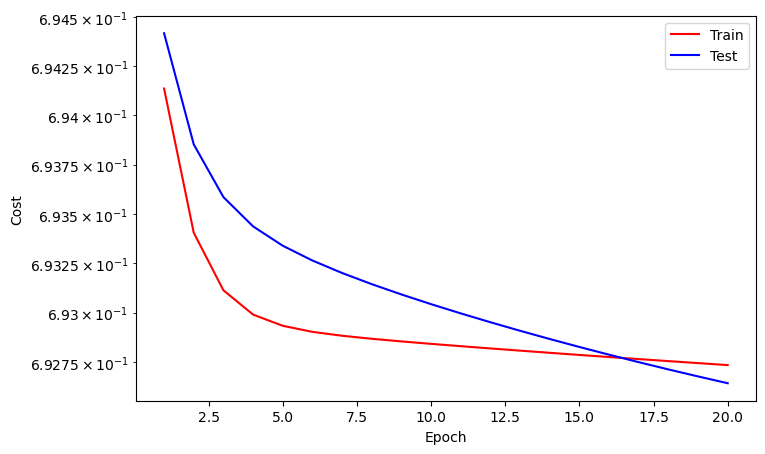

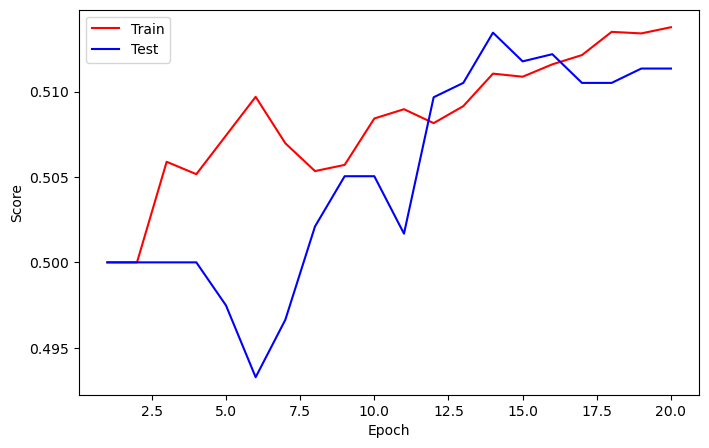

==> EarlyStop patience =  6 | Best test_score: 0.5134


─────────────────────────────────────────────────── 🚀 EPOCH 21 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1134.66it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6927 │ 0.6926 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4859 │ 0.4874 │ │ green │  0.5235  │
│ Subset Accuracy  │ 0.4652 │ 0.2639 │ │  red  │  0.5017  │
│ Micro F1         │ 0.4975 │ 0.6097 │ └───────┴──────────┘
│ Macro F1         │ 0.4863 │ 0.5916 │                     
│ Overall Accuracy │ 0.5141 │ 0.5126 │                     
└──────────────────┴────────┴────────┘


Epoch    21
Train_cost  = 0.6927 | Test_cost  = 0.6926 | Train_score = 0.5141 | Test_score = 0.5126 |
==> EarlyStop patience =  7 | Best test_score: 0.5134


...


Epoch    39
Train_cost  = 0.6926 | Test_cost  = 0.6922 | Train_score = 0.5112 | Test_score = 0.5265 |


─────────────────────────────────────────────────── 🚀 EPOCH 40 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1038.19it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6926 │ 0.6922 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4885 │ 0.4714 │ │ green │  0.5303  │
│ Subset Accuracy  │ 0.4669 │ 0.3807 │ │  red  │  0.5269  │
│ Micro F1         │ 0.4981 │ 0.5893 │ └───────┴──────────┘
│ Macro F1         │ 0.4949 │ 0.5375 │                     
│ Overall Accuracy │ 0.5115 │ 0.5286 │                     
└──────────────────┴────────┴────────┘


Epoch    40
Train_cost  = 0.6926 | Test_cost  = 0.6922 | Train_score = 0.5115 | Test_score = 0.5286 |


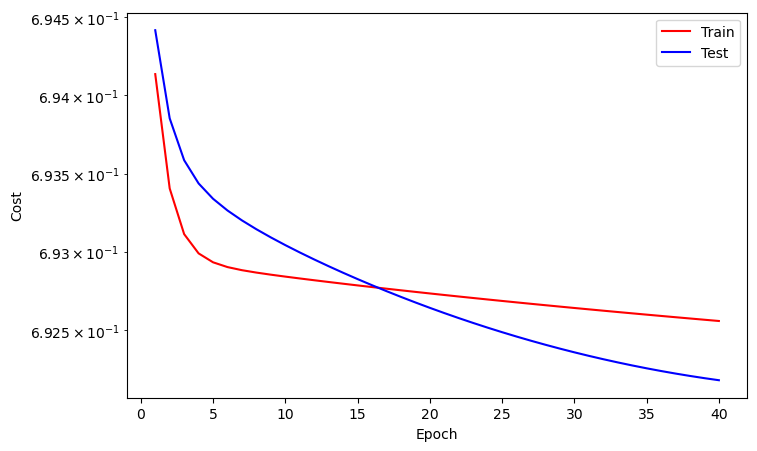

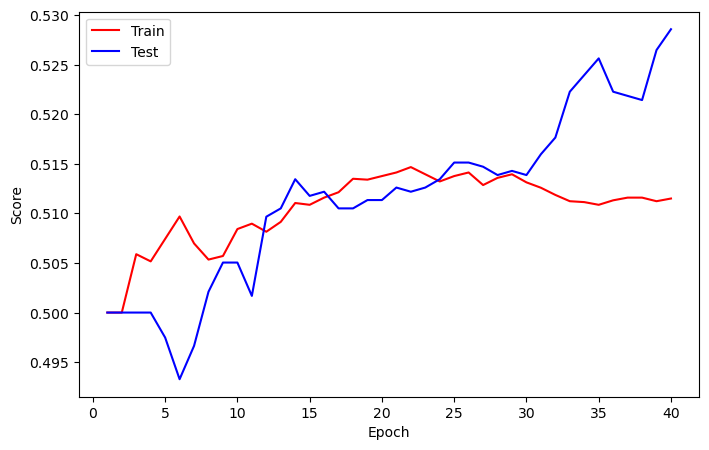

─────────────────────────────────────────────────── 🚀 EPOCH 41 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1103.96it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6926 │ 0.6922 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4878 │ 0.4731 │ │ green │  0.5311  │
│ Subset Accuracy  │ 0.4681 │ 0.3874 │ │  red  │  0.5227  │
│ Micro F1         │ 0.4994 │ 0.5848 │ └───────┴──────────┘
│ Macro F1         │ 0.4964 │ 0.5278 │                     
│ Overall Accuracy │ 0.5122 │ 0.5269 │                     
└──────────────────┴────────┴────────┘


Epoch    41
Train_cost  = 0.6926 | Test_cost  = 0.6922 | Train_score = 0.5122 | Test_score = 0.5269 |
==> EarlyStop patience =  1 | Best test_score: 0.5286


─────────────────────────────────────────────────── 🚀 EPOCH 42 ───────────────────────────────────────────────────

...


Epoch    59
Train_cost  = 0.6924 | Test_cost  = 0.6921 | Train_score = 0.5127 | Test_score = 0.5269 |
==> EarlyStop patience = 19 | Best test_score: 0.5286


─────────────────────────────────────────────────── 🚀 EPOCH 60 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1027.02it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6924 │ 0.6921 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4868 │ 0.4731 │ │ green │  0.5311  │
│ Subset Accuracy  │ 0.4708 │ 0.5059 │ │  red  │  0.5227  │
│ Micro F1         │ 0.5042 │ 0.5366 │ └───────┴──────────┘
│ Macro F1         │ 0.5025 │ 0.3798 │                     
│ Overall Accuracy │ 0.5132 │ 0.5269 │                     
└──────────────────┴────────┴────────┘


Epoch    60
Train_cost  = 0.6924 | Test_cost  = 0.6921 | Train_score = 0.5132 | Test_score = 0.5269 |


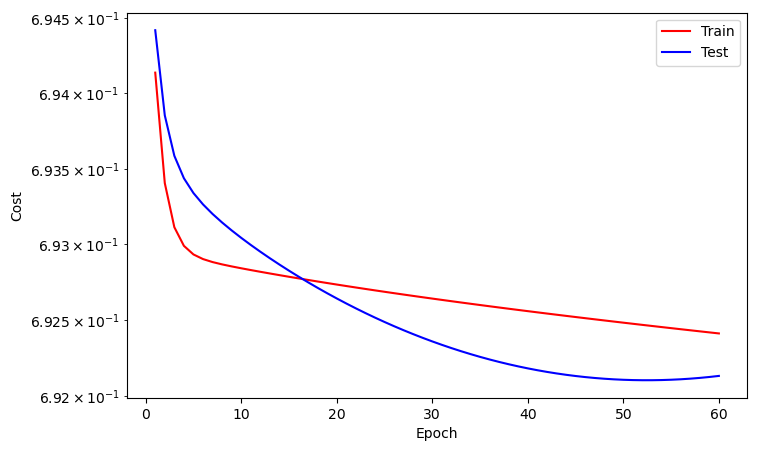

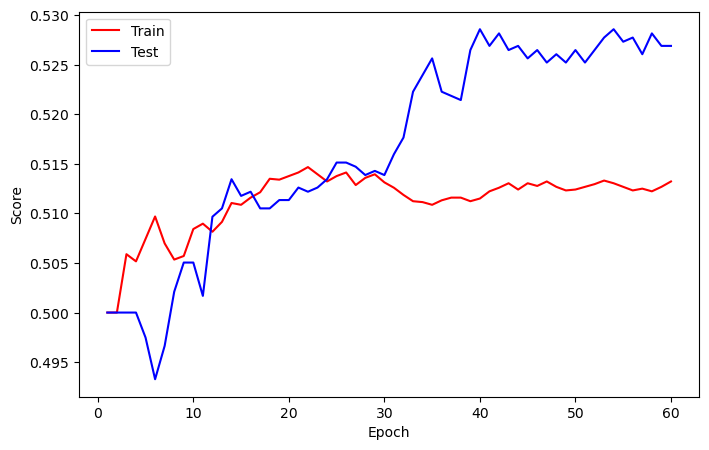

==> EarlyStop patience = 20 | Best test_score: 0.5286


─────────────────────────────────────────────────── 🚀 EPOCH 61 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1057.35it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6924 │ 0.6921 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4869 │ 0.4723 │ │ green │  0.5311  │
│ Subset Accuracy  │ 0.4708 │ 0.5092 │ │  red  │  0.5244  │
│ Micro F1         │ 0.5041 │ 0.5363 │ └───────┴──────────┘
│ Macro F1         │ 0.5024 │ 0.3768 │                     
│ Overall Accuracy │ 0.5131 │ 0.5277 │                     
└──────────────────┴────────┴────────┘


Epoch    61
Train_cost  = 0.6924 | Test_cost  = 0.6921 | Train_score = 0.5131 | Test_score = 0.5277 |
==> EarlyStop patience = 21 | Best test_score: 0.5286


...


Epoch    79
Train_cost  = 0.6923 | Test_cost  = 0.6925 | Train_score = 0.5135 | Test_score = 0.5311 |
==> EarlyStop patience = 15 | Best test_score: 0.5315


─────────────────────────────────────────────────── 🚀 EPOCH 80 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 934.55it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6923 │ 0.6925 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4861 │ 0.4689 │ │ green │  0.5311  │
│ Subset Accuracy  │ 0.4775 │ 0.5311 │ │  red  │  0.5311  │
│ Micro F1         │ 0.5048 │ 0.5311 │ └───────┴──────────┘
│ Macro F1         │ 0.5035 │ 0.3469 │                     
│ Overall Accuracy │ 0.5139 │ 0.5311 │                     
└──────────────────┴────────┴────────┘


Epoch    80
Train_cost  = 0.6923 | Test_cost  = 0.6925 | Train_score = 0.5139 | Test_score = 0.5311 |


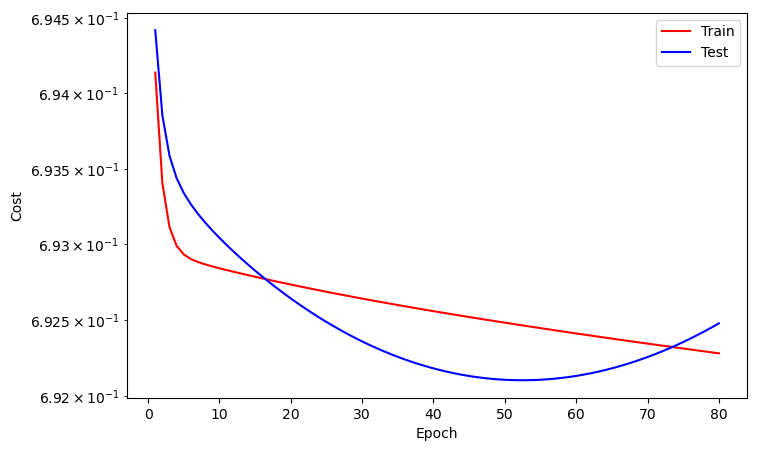

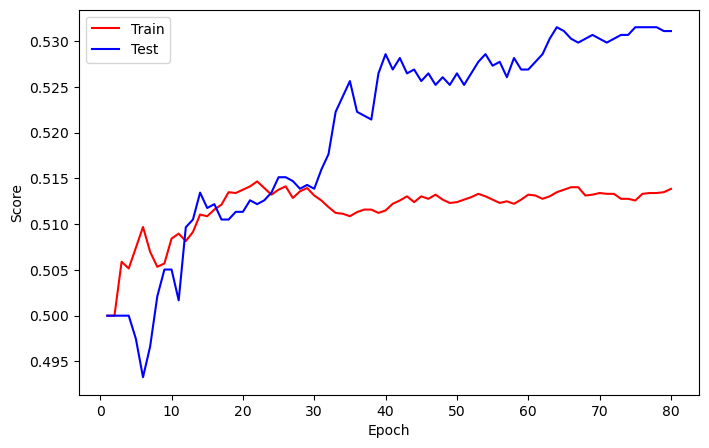

==> EarlyStop patience = 16 | Best test_score: 0.5315


─────────────────────────────────────────────────── 🚀 EPOCH 81 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 947.84it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6923 │ 0.6925 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4862 │ 0.4689 │ │ green │  0.5311  │
│ Subset Accuracy  │ 0.4784 │ 0.5311 │ │  red  │  0.5311  │
│ Micro F1         │ 0.5048 │ 0.5311 │ └───────┴──────────┘
│ Macro F1         │ 0.5034 │ 0.3469 │                     
│ Overall Accuracy │ 0.5138 │ 0.5311 │                     
└──────────────────┴────────┴────────┘


Epoch    81
Train_cost  = 0.6923 | Test_cost  = 0.6925 | Train_score = 0.5138 | Test_score = 0.5311 |
==> EarlyStop patience = 17 | Best test_score: 0.5315


...


Epoch    93
Train_cost  = 0.6922 | Test_cost  = 0.6929 | Train_score = 0.5161 | Test_score = 0.5311 |
==> EarlyStop patience = 29 | Best test_score: 0.5315


─────────────────────────────────────────────────── 🚀 EPOCH 94 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1046.89it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6922 │ 0.6929 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4839 │ 0.4689 │ │ green │  0.5311  │
│ Subset Accuracy  │ 0.4821 │ 0.5311 │ │  red  │  0.5311  │
│ Micro F1         │ 0.5076 │ 0.5311 │ └───────┴──────────┘
│ Macro F1         │ 0.5063 │ 0.3469 │                     
│ Overall Accuracy │ 0.5161 │ 0.5311 │                     
└──────────────────┴────────┴────────┘


Epoch    94
Train_cost  = 0.6922 | Test_cost  = 0.6929 | Train_score = 0.5161 | Test_score = 0.5311 |
==> EarlyStop patience = 30 | Best test_score: 0.5315
==> Execute Early Stopping at epoch: 94 | Best test_score: 0.5315
==> Best model is saved at timeseris/multi-label-clasification/rnn/microsoft_stock_data/


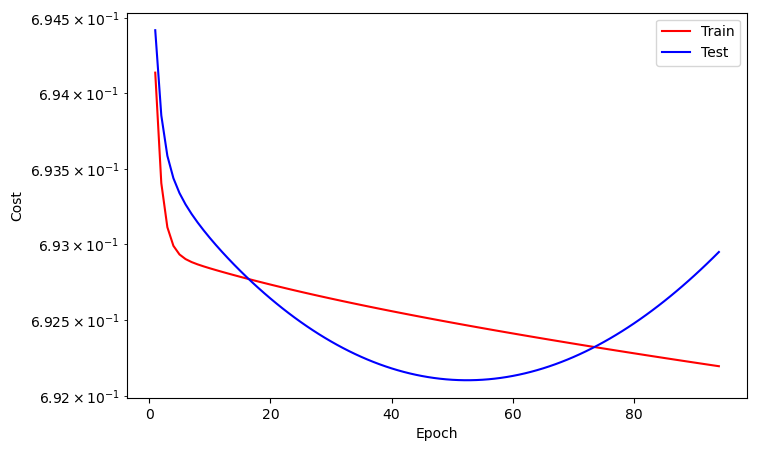

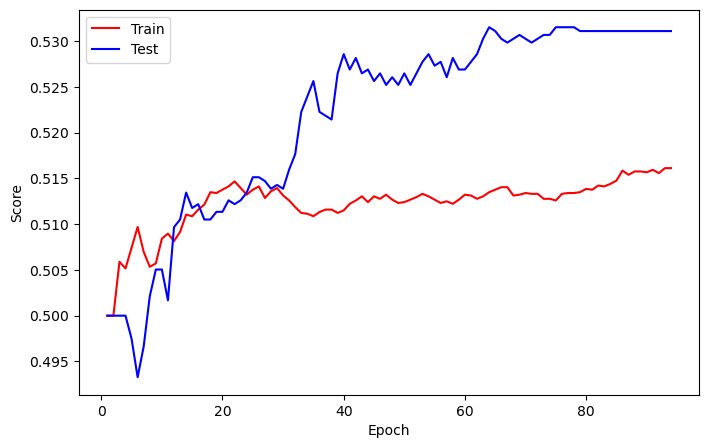

⏹️ Training dihentikan oleh early stopping.

In [20]:
from train_and_evaluate import train_and_evaluate_multi_label

train_and_evaluate_multi_label(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optim=optim,
    config=config,
    device=device,
    labels=labels,          
    callback=callback
)

# Evaluate

In [21]:
from evaluate import evaluate_multi_label

hsl = evaluate_multi_label(model, test_loader, target_cols,criterion, device, config.threshold)

       📊 Evaluasi Model         🎯 Per-Label Accuracy
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━┳━━━━━━━━━┓
┃ Metrik              ┃  Nilai ┃ ┃  Label  ┃ Akurasi ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━╇━━━━━━━━━┩
│ 🔹 Overall Accuracy │ 0.5315 │ │ y_green │ 0.5311  │
│ ✅ Subset  Accuracy │ 0.5202 │ │  y_red  │ 0.5319  │
│ 💥 Loss (avg)       │ 0.6922 │ └─────────┴─────────┘
│ 📉 Hamming Loss     │ 0.4685 │                      
│ ⚖️  Micro F1-score   │ 0.5368 │                      
│ 📈 Macro F1-score   │ 0.3708 │                      
└─────────────────────┴────────┘

In [22]:
hsl = hsl['df']
b = hsl[hsl['Benar (%)'] == 100]
b.head(300)

,Target,Prediksi,Benar (%)
0,"[1.0, 0.0]","[1.0, 0.0]",100.0
1,"[1.0, 0.0]","[1.0, 0.0]",100.0
3,"[1.0, 0.0]","[1.0, 0.0]",100.0
5,"[1.0, 0.0]","[1.0, 0.0]",100.0
7,"[1.0, 0.0]","[1.0, 0.0]",100.0
...,...,...,...
592,"[1.0, 0.0]","[1.0, 0.0]",100.0
593,"[1.0, 0.0]","[1.0, 0.0]",100.0
594,"[1.0, 0.0]","[1.0, 0.0]",100.0
597,"[1.0, 0.0]","[1.0, 0.0]",100.0


In [23]:
b.shape

(619, 3)

In [24]:
s = hsl[hsl['Benar (%)'] == 0]
s.head(300)

,Target,Prediksi,Benar (%)
6,"[0.0, 1.0]","[1.0, 0.0]",0.0
8,"[0.0, 1.0]","[1.0, 0.0]",0.0
9,"[0.0, 1.0]","[1.0, 0.0]",0.0
10,"[0.0, 1.0]","[1.0, 0.0]",0.0
12,"[0.0, 1.0]","[1.0, 0.0]",0.0
...,...,...,...
645,"[0.0, 1.0]","[1.0, 0.0]",0.0
648,"[0.0, 1.0]","[1.0, 0.0]",0.0
650,"[0.0, 1.0]","[1.0, 0.0]",0.0
652,"[0.0, 1.0]","[1.0, 0.0]",0.0


In [25]:
s.shape

(544, 3)